# Sprint 4 — v13: external validation on RSNA Screening Mammography

**Project:** Q-INTERVAL-Lite+ · **Author:** Pasindu Pahasara (104348348)

## What this is for

Every number in this project so far comes from Mammo-Bench. The audit established that models
were reading dataset provenance rather than pathology; Group DRO cut the shortcut slope from
0.813 to 0.287 and the v12 ensemble recovered malignant recall to 0.7643, within 1.7 points of
the Sprint 3 figure.

None of that proves the model works on data it has never seen. RSNA Screening Mammography is
the test, and these are the measured figures from `train.csv`, not estimates:
**54,706 images, 11,913 patients, 23,826 breasts, 1,158 cancers — 2.117% prevalence**,
across 2 sites and 10 scanner models. A genuine screening population rather than a research
collection enriched with cancers.

| | Mammo-Bench test | RSNA |
|---|---|---|
| malignant prevalence | 44.5% | ~2% |
| cancers available | 1,256 images | 1,158 images |
| sites / scanners | 5 research collections | 2 sites, 10 scanner models |
| prior range across groups | 0.042 – 0.797 | 0.004 – 0.035 |
| labels | Normal / Benign / Malignant | cancer 0/1 |

## The confound that will ruin this if it is ignored

Mammo-Bench images are **preprocessed**: format standardisation, breast segmentation, pectoral
muscle removal, intelligent cropping. RSNA ships raw DICOM.

Feeding raw RSNA images to models trained on Mammo-Bench's preprocessed output measures two
things at once — the population shift we want, and a preprocessing shift we do not. A poor
result would be uninterpretable.

So this notebook does two things before it reports anything:

1. **Replicates the preprocessing** — DICOM windowing, MONOCHROME1 inversion, Otsu breast
   segmentation, largest-component crop, resize. Not identical to Mammo-Bench's pipeline;
   close enough to test.

   Note: if you use the 512px PNG release rather than raw DICOM, those images have already
   been windowed, cropped and squashed to square by a third party. That is a *third* pipeline,
   not a second. The section 6a control still bounds the total preprocessing cost, but the
   cleanest run uses the original DICOMs.
2. **Runs a preprocessing control.** The v12 ensemble is re-evaluated on the *Mammo-Bench test
   set passed through this same new pipeline*. The gap between that and the known 0.7643
   isolates the cost of the preprocessing difference, so the RSNA number can be decomposed
   into "different preprocessing" and "different population" rather than reported as one
   unexplained drop.

Without the control this notebook produces a number nobody can interpret. With it, the result
is defensible either way it lands.

## The second thing RSNA gives us

RSNA carries `site_id` and `machine_id`. That is an **independent test of the shortcut
hypothesis on data the models have never seen.** If v12 performs evenly across sites and
scanners, the DRO result generalises. If it splits by scanner, the shortcut was never fixed —
it was fixed only for the five collections it was measured on.

The same slope metric applies, computed over sites instead of source collections.

## What gets reported

Screening metrics, because a 44.5%-prevalence accuracy figure means nothing here: ROC-AUC,
sensitivity and specificity at fixed operating points, PPV, recall rate per 1,000 and cancer
detection rate per 1,000 — the form screening programmes publish, and the first numbers in this
project that can be set against commercial systems without a caveat about cohort enrichment.

## 1. Configuration

In [1]:
import os   # needed here: this cell runs before the imports in section 2

# ---------------- CONFIG ----------------
# Runs on Kaggle (competition pre-mounted, no download) or Colab (needs a download).
# Everything below is resolved per environment in section 2.

ON_KAGGLE = os.path.isdir('/kaggle/input')

# On Kaggle: create ONE private dataset holding the model bundles and frozen_split.json,
# add it to the notebook, and put its slug here.
KAGGLE_BUNDLE_DATASET = 'qinterval-bundles'      # -> /kaggle/input/qinterval-bundles
# Optional second dataset with the Mammo-Bench TEST images, for the preprocessing control.
# Leave as None to skip the control.
KAGGLE_MAMMOBENCH_DATASET = None                 # e.g. 'mammobench-test-split'

# Alternative to uploading a Kaggle dataset: pull the Mammo-Bench control set straight from
# Google Drive. Paste a share link or the bare file ID of a ZIP that contains the test
# images plus metadata.csv.
#   REQUIRES  Settings -> Internet -> On   (Kaggle needs your phone verified to enable it)
#   The share must be set to "Anyone with the link".
# Build a small zip first rather than shipping the whole dataset - see the note in 2b.
GDRIVE_MAMMOBENCH = None    # e.g. '1AbCdEf...' or the full drive.google.com/file/d/.../view URL

# On Colab only:
DRIVE_ROOT = '/content/drive/MyDrive/momobench-dataset'

RSNA_MODE = 'dicom'     # 'dicom' = original competition pixels (default on Kaggle)
                        # 'png'   = community 512px release, third-party preprocessed
KAGGLE_PNG_DATASET = 'theoviel/rsna-breast-cancer-512-pngs'

RSNA_CSV      = None    # resolved in section 2
RSNA_IMG_ROOT = None
RSNA_IMG_SUBDIR = None  # None = auto-detect the layout by probing real filenames

# ---- sampling ----
# MEASURED, not assumed: a full pass costs ~258 ms/image wall-clock on Kaggle's 4 vCPUs,
# because a 10 MP JPEG2000 DICOM takes ~780 ms to decode and the windowing another ~200 ms.
# All 54,706 images is therefore ~3.9 h PER MODEL. Subsampling negatives is the difference
# between a 45-minute run and an overnight one.
#
# It costs almost nothing statistically: sensitivity and specificity are unaffected by the
# negative sampling rate, and PPV / recall rate are projected analytically to the true
# prevalence in section 8. Only the precision of the specificity estimate narrows.
USE_ALL_NEGATIVES = False
NEG_PER_POS       = 12       # 1,158 cancers x 13 = ~15,054 images, ~50 min per model
TRUE_PREVALENCE   = None     # None = measure it from train.csv
DEV_SUBSAMPLE     = 0        # >0 = fast plumbing check. Do this first.

# ---- decode-once cache (usually NOT needed - read this before enabling) ----
# Decoding happens inside DataLoader workers, in parallel with GPU compute, and each
# dataset item yields all 4 TTA views from ONE decode. So the workers only need to supply
# GPU_rate / 4 images per second - about 44/s for EfficientNetV2 and 22/s for ResNet-101.
# Four workers at 25 ms per DICOM manage ~160/s, so the run is GPU-bound and a cache buys
# nothing while costing ~7 idle-GPU minutes to build.
#
# Turn it ON only if the progress bar in section 6 shows the GPU starving (low it/s), which
# happens if Kaggle gives you 2 slow cores. It also makes repeat runs instant.
BUILD_CACHE = False
CACHE_DIR   = '/tmp/rsna_cache' if ON_KAGGLE else '/content/rsna_cache'
CACHE_SIZE  = 640            # just above the largest model input (512), so no upsampling
CACHE_WORKERS = 0            # 0 = os.cpu_count()

TTA_VIEWS = ['none', 'hflip', 'vflip', 'both']

RUN_PREPROC_CONTROL = True   # auto-disabled in section 2 if Mammo-Bench is not present

# Reference points on the Mammo-Bench test set, native preprocessing, 4-view TTA:
V12_INTERNAL = {'mal_recall': 0.7643, 'macro_auc': 0.8810, 'slope': 0.2868}

BATCH_ITEMS = 8              # GPU sees BATCH_ITEMS * len(TTA_VIEWS) images per pass
# ----------------------------------------
print('environment :', 'KAGGLE' if ON_KAGGLE else 'COLAB')
print('RSNA mode   :', RSNA_MODE, '| all negatives:', USE_ALL_NEGATIVES)
print('cache       :', CACHE_DIR)
print(f'GPU sees {BATCH_ITEMS} x {len(TTA_VIEWS)} = {BATCH_ITEMS*len(TTA_VIEWS)} images per pass')

environment : KAGGLE
RSNA mode   : dicom | all negatives: False
cache       : /tmp/rsna_cache
GPU sees 8 x 4 = 32 images per pass


## 2. Setup

**Running this on Kaggle** avoids the whole storage problem — the competition is already
mounted at `/kaggle/input/rsna-breast-cancer-detection`, so there is nothing to download and
no 300 GB to find room for.

Before running, in the Kaggle notebook editor:

1. **Add Data → Competitions →** `rsna-breast-cancer-detection`
2. **Add Data → Your Datasets →** a private dataset containing
   `final_v12_ensemble_bundle.pth`, the two member bundles it names, and `frozen_split.json`.
   Roughly 260 MB. Set `KAGGLE_BUNDLE_DATASET` above to its slug.
3. *Optional:* a second private dataset with the 2,821 Mammo-Bench **test** images plus
   `metadata.csv`, so section 6a can run the preprocessing control. Without it the control is
   skipped and the external number cannot be decomposed — worth the upload.
4. **Settings → Accelerator → GPU T4 x2** (not P100 — its compute capability is too old
   for the PyTorch in Kaggle's image)
5. For the full run use **Save Version → Save & Run All (Commit)** rather than the
   interactive session. It runs headless in the background, survives you closing the tab,
   and reliably keeps everything written to `/kaggle/working`. An interactive session is
   capped at 12 hours and loses unsaved state when it expires.

On Colab the same notebook still works; it mounts Drive and downloads instead.

In [2]:
import os, subprocess
subprocess.run('pip install -q albumentations scikit-learn tqdm matplotlib seaborn '
               'pydicom dicomsdl', shell=True)

import json, math, random, glob, shutil
import numpy as np
import pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet101, efficientnet_v2_s
import cv2, albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from scipy.stats import beta as _beta
import matplotlib.pyplot as plt, seaborn as sns
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
CLASS_NAMES = ['Normal', 'Benign', 'Malignant']
MAL = 2
print('Device:', device)

# Fail here with something readable rather than 200 frames deep in a CUDA kernel launch.
# Kaggle's P100 is compute capability 6.0; current PyTorch builds ship kernels for 7.0+.
if torch.cuda.is_available():
    cap = torch.cuda.get_device_capability(0)
    name = torch.cuda.get_device_name(0)
    print(f'GPU: {name}  (compute capability {cap[0]}.{cap[1]})')
    if cap[0] < 7:
        raise RuntimeError(
            f'{name} is compute capability {cap[0]}.{cap[1]}, but this PyTorch build only '
            f'has kernels for 7.0 and above. Running would fail with '
            f'"no kernel image is available for execution on the device".\n'
            f'FIX: Settings -> Accelerator -> GPU T4 x2  (T4 is 7.5, and faster than P100 '
            f'for fp16 inference anyway).')
else:
    print('WARNING: no GPU. Settings -> Accelerator -> GPU T4 x2. '
          'On CPU this run would take many hours.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.3 MB/s eta 0:00:00
Device: cuda
GPU: Tesla T4  (compute capability 7.5)


In [3]:
# ---------------- resolve paths for this environment ----------------
# Kaggle mounts inputs differently depending on the notebook version - sometimes
# /kaggle/input/<slug>, sometimes /kaggle/input/competitions/<slug> and
# /kaggle/input/datasets/<user>/<slug>. So do not guess directory names: search for the
# actual files. Image folders are pruned from the walk, otherwise enumerating 11,913
# patient sub-folders makes this crawl.

SKIP_DIRS = {'train_images', 'test_images', 'images'}

def _walk(root, maxdepth=6):
    root = root.rstrip('/'); base = root.count(os.sep)
    for r, dirs, fs in os.walk(root):
        if r.count(os.sep) - base >= maxdepth:
            dirs[:] = []
        else:
            dirs[:] = [d for d in dirs if d not in SKIP_DIRS]
        yield r, dirs, fs

def _find(root, name):
    if not root: return None
    for r, dirs, fs in _walk(root):
        if name in fs: return os.path.join(r, name)
    return None

def _find_dir(root, name):
    if not root: return None
    for r, dirs, fs in os.walk(root):
        if name in dirs: return os.path.join(r, name)
        if r.count(os.sep) - root.rstrip('/').count(os.sep) >= 6: dirs[:] = []
    return None


if ON_KAGGLE:
    IN = '/kaggle/input'
    print('under /kaggle/input:')
    for r, dirs, fs in _walk(IN, maxdepth=3):
        d = r.replace(IN, '') or '/'
        print(f'   {d:52s} {len(dirs)} dirs, {len(fs)} files'
              + (f'   e.g. {fs[0]}' if fs else ''))

    # --- competition: locate it by its train_images folder ---
    ti = _find_dir(IN, 'train_images')
    assert ti, ('train_images not found anywhere under /kaggle/input. '
                'Add Data -> Competitions -> rsna-breast-cancer-detection')
    RSNA_IMG_ROOT = os.path.dirname(ti)
    RSNA_CSV = _find(RSNA_IMG_ROOT, 'train.csv') or _find(IN, 'train.csv')
    assert RSNA_CSV, 'train.csv not found under the competition folder'

    # --- model bundles: locate by filename, wherever the dataset was mounted ---
    ENSEMBLE_BUNDLE = _find(IN, 'final_v12_ensemble_bundle.pth')
    assert ENSEMBLE_BUNDLE, (
        'final_v12_ensemble_bundle.pth not found under /kaggle/input. '
        'Attach the dataset containing your model bundles.')
    BUNDLE_ROOT = os.path.dirname(ENSEMBLE_BUNDLE)

    MB_ROOT = IN            # metadata.csv is searched for below, wherever it sits
    OUT_DIR = '/kaggle/working'
else:
    from google.colab import drive
    drive.mount('/content/drive')
    subprocess.run('pip install -q kagglehub', shell=True)
    import kagglehub
    os.system('df -h /content | tail -1')

    if RSNA_MODE == 'dicom':
        if RSNA_IMG_ROOT is None:
            print('downloading the full competition - 300+ GB, do not interrupt')
            RSNA_IMG_ROOT = kagglehub.competition_download('rsna-breast-cancer-detection')
        if RSNA_CSV is None:
            RSNA_CSV = os.path.join(RSNA_IMG_ROOT, 'train.csv')
    else:
        if RSNA_CSV is None:
            RSNA_CSV = kagglehub.competition_download('rsna-breast-cancer-detection',
                                                      path='train.csv')
        if RSNA_IMG_ROOT is None:
            RSNA_IMG_ROOT = kagglehub.dataset_download(KAGGLE_PNG_DATASET)

    BUNDLE_ROOT = DRIVE_ROOT
    MB_ROOT     = DRIVE_ROOT
    OUT_DIR     = os.path.join(DRIVE_ROOT, 'checkpoints_v13_rsna')
    ENSEMBLE_BUNDLE = _find(BUNDLE_ROOT, 'final_v12_ensemble_bundle.pth')
    assert ENSEMBLE_BUNDLE, f'final_v12_ensemble_bundle.pth not found under {BUNDLE_ROOT}'

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

print('\ntrain.csv   ->', RSNA_CSV)
print('images      ->', RSNA_IMG_ROOT)
print('v12 bundle  ->', ENSEMBLE_BUNDLE)
print('bundle root ->', BUNDLE_ROOT)
print('outputs     ->', OUT_DIR)
print('cache       ->', CACHE_DIR)

# the control needs Mammo-Bench; disable it cleanly rather than failing later
MB_CSV = None
if RUN_PREPROC_CONTROL:
    MB_CSV = _find(MB_ROOT, 'metadata.csv')

    # not attached as a dataset - try Google Drive
    if not MB_CSV and GDRIVE_MAMMOBENCH:
        try:
            subprocess.run('pip install -q gdown', shell=True)
            import gdown
            zp = '/tmp/mammobench.zip'
            if not os.path.exists(zp):
                print('\nfetching the control set from Google Drive...')
                gdown.download(url=(GDRIVE_MAMMOBENCH
                                    if GDRIVE_MAMMOBENCH.startswith('http')
                                    else f'https://drive.google.com/uc?id={GDRIVE_MAMMOBENCH}'),
                               output=zp, quiet=False, fuzzy=True)
            assert os.path.exists(zp) and os.path.getsize(zp) > 10_000, 'download failed or empty'
            os.makedirs('/tmp/mammobench', exist_ok=True)
            os.system(f'unzip -q -o {zp} -d /tmp/mammobench')
            MB_ROOT = '/tmp/mammobench'
            MB_CSV = _find(MB_ROOT, 'metadata.csv')
            print('unzipped ->', MB_ROOT, '| metadata.csv:', bool(MB_CSV))
        except Exception as e:
            print('\nGoogle Drive fetch failed:', repr(e))
            print('Common causes:')
            print('  - Settings -> Internet is OFF (needs phone verification on Kaggle)')
            print('  - the file is not shared as "Anyone with the link"')
            print('  - Google rate-limited it ("too many users have viewed or downloaded")')
            print('Uploading the zip as a Kaggle dataset always works and avoids all three.')

    if not MB_CSV:
        RUN_PREPROC_CONTROL = False
        print('\nNOTE: Mammo-Bench metadata.csv not found - preprocessing control DISABLED.')
        print('The RSNA figure then cannot be split into preprocessing cost vs population')
        print('shift. Attach the Mammo-Bench test images to recover it.')
    else:
        print('control set ->', MB_CSV)

under /kaggle/input:
   /                                                    2 dirs, 0 files
   /competitions                                        1 dirs, 0 files
   /competitions/rsna-breast-cancer-detection           0 dirs, 3 files   e.g. sample_submission.csv
   /datasets                                            1 dirs, 0 files
   /datasets/pasindupahasara                            2 dirs, 0 files
   /datasets/pasindupahasara/mammobench-test-control    0 dirs, 1 files   e.g. metadata.csv
   /datasets/pasindupahasara/qinterval-bundles          0 dirs, 4 files   e.g. final_v8_resnet101_nosrc_ce_bundle.pth

train.csv   -> /kaggle/input/competitions/rsna-breast-cancer-detection/train.csv
images      -> /kaggle/input/competitions/rsna-breast-cancer-detection
v12 bundle  -> /kaggle/input/datasets/pasindupahasara/qinterval-bundles/final_v12_ensemble_bundle.pth
bundle root -> /kaggle/input/datasets/pasindupahasara/qinterval-bundles
outputs     -> /kaggle/working
cache       -> /tmp/rs

### 2b. Getting the Mammo-Bench control set here

The preprocessing control needs the 2,821 Mammo-Bench **test** images and `metadata.csv`.
Two ways to get them onto Kaggle, and the second has fewer ways to fail.

**Via Google Drive** — set `GDRIVE_MAMMOBENCH` in the config to a share link or file ID.
Two conditions, and both bite silently if missed:

- **Settings → Internet → On.** Off by default, and Kaggle requires a verified phone number
  before it will let you enable it.
- The file must be shared as **"Anyone with the link"**, not "Restricted".

Large public files also sometimes hit Google's rate limiter with *"too many users have viewed
or downloaded this file recently"*, which no amount of retrying fixes quickly.

**Build a small zip first.** Do not ship the whole 19,731-image dataset for a 2,821-image
control. Run this once in Colab, where the data is already mounted, and put the result on
Drive:

```python
import json, os, zipfile, pandas as pd
ROOT  = '/content/dataset_original/dataset'
SPLIT = '/content/drive/MyDrive/momobench-dataset/sprint4_audit/frozen_split.json'
test_ids = set(json.load(open(SPLIT))['test'])
mb = pd.read_csv(f'{ROOT}/metadata.csv')
mb = mb[mb.source_subjectID.isin(test_ids) & (mb.source_dataset != 'cdd-cesm')]
out = '/content/drive/MyDrive/mammobench_test_control.zip'
with zipfile.ZipFile(out, 'w', zipfile.ZIP_STORED) as z:
    z.write(f'{ROOT}/metadata.csv', 'metadata.csv')
    for p in mb.preprocessed_image_path:
        fp = os.path.join(ROOT, p)
        if os.path.exists(fp): z.write(fp, p)
print(out, os.path.getsize(out)/1e6, 'MB', len(mb), 'images')
```

**Or upload that same zip as a Kaggle dataset** and attach it. No internet setting, no share
permissions, no rate limits — the notebook finds `metadata.csv` wherever it lands.

Either way the notebook copes: if it cannot find the control set it disables it, says so
plainly, and the rest of the run still produces the RSNA numbers.

## 3. RSNA metadata and the evaluation sample

In [4]:
rsna = pd.read_csv(RSNA_CSV if os.path.isfile(RSNA_CSV)
                   else os.path.join(RSNA_CSV, 'train.csv'))
print('rows:', len(rsna), '| columns:', list(rsna.columns))

FULL_PREV = rsna['cancer'].mean()
PREV = FULL_PREV if TRUE_PREVALENCE is None else TRUE_PREVALENCE
print(f'\nimage-level cancer prevalence in the full release: {FULL_PREV:.4f} '
      f'({int(rsna.cancer.sum())} of {len(rsna)})')
print(f'patients: {rsna.patient_id.nunique()}   sites: {sorted(rsna.site_id.unique())}')
print('\nby site:')
print(rsna.groupby('site_id').agg(images=('cancer','size'), cancers=('cancer','sum'),
                                  prevalence=('cancer','mean')).round(4).to_string())
if 'machine_id' in rsna.columns:
    print('\nby scanner (machine_id):')
    print(rsna.groupby('machine_id').agg(images=('cancer','size'), cancers=('cancer','sum'),
                                         prevalence=('cancer','mean')).round(4).to_string())

# ---- build the evaluation sample: all cancers + stratified negatives ----
if USE_ALL_NEGATIVES:
    ev = rsna.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    print('\nusing EVERY image - specificity will be measured, not estimated')
else:
    pos = rsna[rsna.cancer == 1]
    negs = []
    for site, grp in rsna[rsna.cancer == 0].groupby('site_id'):
        n_pos_site = int((rsna[(rsna.site_id == site)].cancer == 1).sum())
        take = min(len(grp), n_pos_site * NEG_PER_POS)
        negs.append(grp.sample(n=take, random_state=SEED))
    ev = pd.concat([pos, pd.concat(negs)]).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    print(f'\nsubsampled negatives at {NEG_PER_POS} per cancer')
if DEV_SUBSAMPLE:
    ev = ev.head(DEV_SUBSAMPLE).reset_index(drop=True)
    print(f'\nDEV_SUBSAMPLE active - only {len(ev)} images, results are plumbing only')

# ---- work out how this release lays its files out, rather than assuming ----
import glob as _glob
ext = '.png' if RSNA_MODE == 'png' else '.dcm'

def _find_image_dirs():
    cands = []
    for root, dirs, files in os.walk(RSNA_IMG_ROOT):
        if any(fn.endswith(ext) for fn in files[:50]):
            cands.append(root)
        if len(cands) > 400: break
    return cands

_dirs = _find_image_dirs()
if not _dirs:
    raise FileNotFoundError(f'no *{ext} files anywhere under {RSNA_IMG_ROOT} - '
                            f'check RSNA_MODE and that the download completed')

# nested layout puts images in per-patient subfolders; flat puts them all in one
_nested_roots = sorted({os.path.dirname(d) for d in _dirs if os.path.basename(d).isdigit()})
_flat_roots   = sorted({d for d in _dirs if not os.path.basename(d).isdigit()})

PATTERNS = []
for r in _nested_roots:
    PATTERNS.append(('nested', r, lambda row, r=r: os.path.join(r, str(row.patient_id),
                                                                f'{row.image_id}{ext}')))
for r in _flat_roots:
    PATTERNS.append(('flat_pid_iid', r, lambda row, r=r: os.path.join(r, f'{row.patient_id}_{row.image_id}{ext}')))
    PATTERNS.append(('flat_iid',     r, lambda row, r=r: os.path.join(r, f'{row.image_id}{ext}')))
if RSNA_IMG_SUBDIR:
    r = os.path.join(RSNA_IMG_ROOT, RSNA_IMG_SUBDIR)
    PATTERNS.insert(0, ('override', r, lambda row, r=r: os.path.join(r, str(row.patient_id),
                                                                     f'{row.image_id}{ext}')))

probe = ev.head(40)
best, best_hits = None, -1
print('\nresolving image layout:')
for name, root, fn in PATTERNS:
    hits = sum(os.path.exists(fn(r)) for r in probe.itertuples())
    print(f'   {name:14s} {root[:70]:70s} {hits}/{len(probe)}')
    if hits > best_hits: best, best_hits = (name, root, fn), hits
if best_hits == 0:
    example = _dirs[0]
    raise FileNotFoundError(
        'none of the candidate layouts matched. Files exist here:\n  '
        + example + '\n  e.g. ' + str(sorted(os.listdir(example))[:3])
        + '\nSet RSNA_IMG_SUBDIR, or adjust PATTERNS to match.')
print(f'-> using {best[0]} at {best[1]}  ({best_hits}/{len(probe)} probe hits)')

ev['path'] = [best[2](r) for r in ev.itertuples()]
missing = (~ev['path'].apply(os.path.exists)).sum()
if missing:
    print(f'WARNING {missing} of {len(ev)} files still not found - dropping them')
    ev = ev[ev['path'].apply(os.path.exists)].reset_index(drop=True)

# TRUE per-group prevalence, taken from the FULL release. Critical: the negative sampling
# above gives every site a sample prevalence of exactly 1/(1+NEG_PER_POS), so a shortcut
# slope computed against SAMPLE prior would be structurally zero and read as a pass no
# matter what the model does. Section 9 must use these.
TRUE_PRIOR = {'site_id': rsna.groupby('site_id')['cancer'].mean().to_dict()}
if 'machine_id' in rsna.columns:
    TRUE_PRIOR['machine_id'] = rsna.groupby('machine_id')['cancer'].mean().to_dict()
print('\nTRUE prevalence per site (from the full release, not the sample):')
for k, v in TRUE_PRIOR['site_id'].items(): print(f'   site {k}: {v:.4f}')

print(f'\nEVALUATION SAMPLE: {len(ev)} images   '
      f'{int(ev.cancer.sum())} cancers   sample prevalence {ev.cancer.mean():.4f}')
print(f'metrics will be projected back to the true prevalence of {PREV:.4f} in section 8')
print(ev.groupby('site_id').agg(images=('cancer','size'), cancers=('cancer','sum')).to_string())

rows: 54706 | columns: ['site_id', 'patient_id', 'image_id', 'laterality', 'view', 'age', 'cancer', 'biopsy', 'invasive', 'BIRADS', 'implant', 'density', 'machine_id', 'difficult_negative_case']

image-level cancer prevalence in the full release: 0.0212 (1158 of 54706)
patients: 11913   sites: [np.int64(1), np.int64(2)]

by site:
         images  cancers  prevalence
site_id                             
1         29519      664      0.0225
2         25187      494      0.0196

by scanner (machine_id):
            images  cancers  prevalence
machine_id                             
21            8221      154      0.0187
29            8267      161      0.0195
48            8699      179      0.0206
49           23529      614      0.0261
93            1915       14      0.0073
170            923       23      0.0249
190            145        5      0.0345
197             29        0      0.0000
210           1070        0      0.0000
216           1908        8      0.0042

subsampled ne

## 4. Preprocessing — approximating the Mammo-Bench pipeline

Four steps, applied identically to RSNA and (in section 6) to the Mammo-Bench control:

1. **Load and normalise.** DICOM pixel data windowed to 0–255; MONOCHROME1 images inverted so
   breast tissue is bright on a dark background, as in Mammo-Bench.
2. **Segment the breast.** Otsu threshold, then keep the largest connected component. Removes
   the background, labels burnt into the corner, and most scanner artefacts.
3. **Crop.** Bounding box of that component — Mammo-Bench's "intelligent cropping".
4. **Resize** to each model's training resolution.

**Pectoral muscle removal is not implemented.** Mammo-Bench does it; doing it well needs a
dedicated model. This is the main residual difference between the two pipelines, and it is
exactly what the section 6 control is there to quantify.

In [5]:
# Everything downstream feeds a 384-512 px model, so there is no reason to window, threshold
# and label connected components at 10 megapixels. Downscaling first cuts the non-decode part
# of preprocessing from ~253 ms to ~27 ms per image (measured).
PREPROC_MAX_SIDE = 1024


def _shrink(a, max_side=None):
    m = max_side or PREPROC_MAX_SIDE
    h, w = a.shape[:2]
    if max(h, w) <= m: return a
    sc = m / max(h, w)
    return cv2.resize(a, (max(1, int(w*sc)), max(1, int(h*sc))), interpolation=cv2.INTER_AREA)


def load_raw(path):
    # Returns a uint8 grayscale array, breast bright on dark, regardless of source format.
    if path.endswith('.dcm'):
        try:
            import dicomsdl
            d = dicomsdl.open(path)
            a = d.pixelData()
            invert = (d.getPixelDataInfo().get('PhotometricInterpretation', '') == 'MONOCHROME1')
        except Exception:
            import pydicom
            d = pydicom.dcmread(path)
            a = d.pixel_array
            invert = (getattr(d, 'PhotometricInterpretation', '') == 'MONOCHROME1')
        a = _shrink(a).astype(np.float32)      # shrink BEFORE the percentile - it is O(pixels)
        lo, hi = np.percentile(a, [1, 99])
        a = np.clip((a - lo) / max(hi - lo, 1e-6), 0, 1)
        if invert: a = 1.0 - a
        return (a * 255).astype(np.uint8)
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None: raise FileNotFoundError(path)
    img = _shrink(img)
    # a pre-converted PNG whose border is bright has not been inverted
    if img[:8, :8].mean() > 127: img = 255 - img
    return img


def crop_breast(img, pad=8):
    # Otsu + largest connected component + bounding box.
    blur = cv2.GaussianBlur(img, (5, 5), 0)
    _, m = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((7, 7), np.uint8))
    n, lab, stats, _ = cv2.connectedComponentsWithStats(m, 8)
    if n <= 1: return img
    k = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
    x, y, w, h = (stats[k, cv2.CC_STAT_LEFT], stats[k, cv2.CC_STAT_TOP],
                  stats[k, cv2.CC_STAT_WIDTH], stats[k, cv2.CC_STAT_HEIGHT])
    if w < img.shape[1] * 0.10 or h < img.shape[0] * 0.10: return img
    y0, y1 = max(0, y-pad), min(img.shape[0], y+h+pad)
    x0, x1 = max(0, x-pad), min(img.shape[1], x+w+pad)
    out = img[y0:y1, x0:x1]
    return out if out.size else img


def preprocess(path):
    return cv2.cvtColor(crop_breast(load_raw(path)), cv2.COLOR_GRAY2RGB)


# Which decoder are we actually getting? dicomsdl is several times faster than
# pydicom + pylibjpeg on JPEG2000, and the difference here is hours.
if RSNA_MODE == 'dicom':
    try:
        import dicomsdl  # noqa: F401
        print('DICOM decoder: dicomsdl (fast path)')
    except Exception:
        print('DICOM decoder: pydicom fallback - SEVERAL TIMES SLOWER on JPEG2000.')
        print('  try:  !pip install -q dicomsdl   and restart the session')

    import time as _t
    _p = ev['path'].iloc[0] if 'path' in ev.columns else None
    if _p:
        _t0 = _t.perf_counter(); preprocess(_p); _d = _t.perf_counter() - _t0
        _n = len(ev); _w = max(2, (os.cpu_count() or 2))
        print(f'measured: {_d*1000:.0f} ms/image single-threaded')
        print(f'estimate: {_n*_d/_w/3600:.2f} h per model pass over {_n:,} images '
              f'with {_w} workers')
        if _n * _d / _w / 3600 > 1.5:
            print('  -> over 1.5 h per model. Consider USE_ALL_NEGATIVES = False, '
                  'or a smaller NEG_PER_POS.')

DICOM decoder: dicomsdl (fast path)
measured: 2085 ms/image single-threaded
estimate: 2.18 h per model pass over 15,054 images with 4 workers
  -> over 1.5 h per model. Consider USE_ALL_NEGATIVES = False, or a smaller NEG_PER_POS.


### 4a. Look at it before trusting it

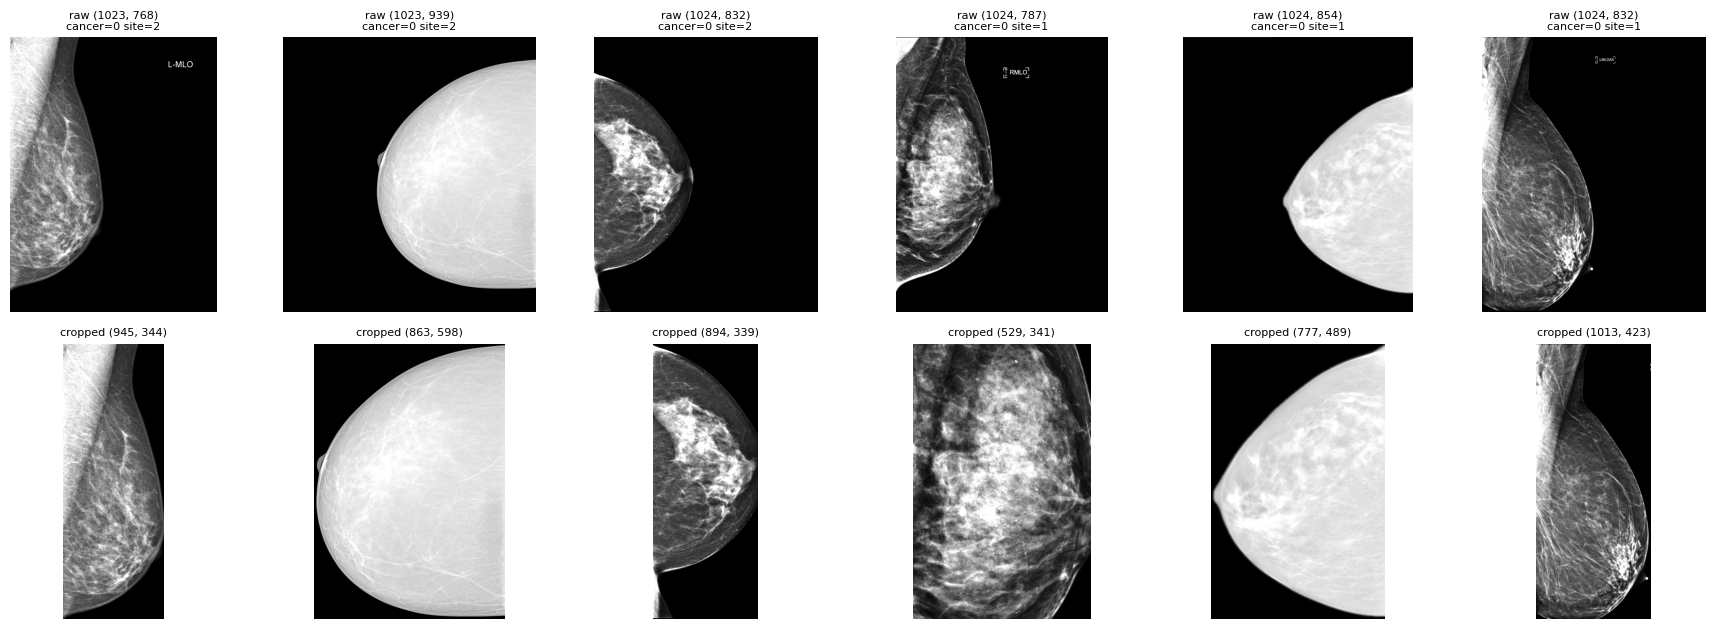

Top row must show breast tissue BRIGHT on a DARK background. If any is inverted,
the load_raw heuristic has misfired on that source and the whole run is invalid.


In [6]:
sample = ev.sample(n=min(6, len(ev)), random_state=1)
fig, ax = plt.subplots(2, len(sample), figsize=(3*len(sample), 6.4))
for j, (_, r) in enumerate(sample.iterrows()):
    raw = load_raw(r['path']); crop = crop_breast(raw)
    ax[0, j].imshow(raw, cmap='gray');  ax[0, j].axis('off')
    ax[0, j].set_title(f"raw {raw.shape}\ncancer={int(r.cancer)} site={int(r.site_id)}", fontsize=8)
    ax[1, j].imshow(crop, cmap='gray'); ax[1, j].axis('off')
    ax[1, j].set_title(f'cropped {crop.shape}', fontsize=8)
plt.tight_layout(); plt.show()
print('Top row must show breast tissue BRIGHT on a DARK background. If any is inverted,')
print('the load_raw heuristic has misfired on that source and the whole run is invalid.')

### 4b. Optional decode-once cache — off by default, and here is why

This step is **CPU only**. It decodes DICOMs, crops them and writes PNGs; the GPU is idle
for the whole 20–40 minutes. So it is worth asking whether it earns that.

Mostly it does not. Decoding runs inside the DataLoader workers **in parallel with GPU
compute**, and since each dataset item yields all four TTA views from a single decode, the
workers only need to supply GPU-rate ÷ 4 images per second:

| | GPU needs | 4 workers supply |
|---|---|---|
| EfficientNetV2-S 384px | ~44 DICOM/s | ~160 DICOM/s |
| ResNet-101 512px | ~23 DICOM/s | ~160 DICOM/s |

The run is GPU-bound either way, so the cache saves nothing and costs idle GPU minutes.
`BUILD_CACHE` is therefore **False** by default and this section is skipped.

**Turn it on if** the progress bar in section 6 shows the GPU starving — a low iterations/sec
that does not improve — which happens if Kaggle allocates only two slow cores. It also makes
repeat runs instant, which is worth having if you expect to re-run after attaching the
Mammo-Bench control set.

When enabled it is safe to interrupt and re-run: it skips anything already written.

In [7]:
from concurrent.futures import ProcessPoolExecutor
import functools

os.makedirs(CACHE_DIR, exist_ok=True)

def _cache_path(image_id):
    return os.path.join(CACHE_DIR, f'{image_id}.png')

def _build_one(args):
    src, image_id, size = args
    dst = os.path.join(CACHE_DIR, f'{image_id}.png')
    if os.path.exists(dst):
        return 0
    try:
        img = crop_breast(load_raw(src))
        h, w = img.shape[:2]
        scale = size / max(h, w)
        if scale < 1.0:
            img = cv2.resize(img, (max(1, int(w*scale)), max(1, int(h*scale))),
                             interpolation=cv2.INTER_AREA)
        cv2.imwrite(dst, img)
        return 1
    except Exception:
        return -1

if not BUILD_CACHE:
    # Read the source images directly. preprocess() runs inside the DataLoader workers,
    # overlapped with GPU compute.
    IMG_COL, IMG_CACHED = 'path', False
    print('cache disabled - decoding on the fly inside the DataLoader workers.')
    print('If section 6 shows the GPU starving, set BUILD_CACHE = True and re-run.')

if BUILD_CACHE:
    IMG_COL, IMG_CACHED = 'cache_path', True
    todo = [(r['path'], r['image_id'], CACHE_SIZE) for _, r in ev.iterrows()
            if not os.path.exists(_cache_path(r['image_id']))]
    print(f'{len(ev) - len(todo)} already cached, {len(todo)} to build')
    if todo:
        nw = CACHE_WORKERS or (os.cpu_count() or 2)
        print(f'decoding with {nw} workers - this is the slow part')
        built = failed = 0
        with ProcessPoolExecutor(max_workers=nw) as exe:
            for r in tqdm(exe.map(_build_one, todo, chunksize=32),
                          total=len(todo), desc='cache'):
                if r == 1: built += 1
                elif r == -1: failed += 1
        print(f'built {built}, failed {failed}')
        if failed:
            print('failures are usually unreadable DICOMs - they are dropped below')

    # point the evaluation frame at the cache
    ev['cache_path'] = ev['image_id'].apply(_cache_path)
    have = ev['cache_path'].apply(os.path.exists)
    if (~have).sum():
        print(f'dropping {(~have).sum()} images with no cache entry')
        ev = ev[have].reset_index(drop=True)
    sz = sum(os.path.getsize(p) for p in ev['cache_path'].head(500))
    print(f'cache is roughly {sz/500*len(ev)/1e9:.1f} GB')

print(f'\nready: {len(ev)} images, {int(ev.cancer.sum())} cancers   '
      f'(reading from {IMG_COL})')

cache disabled - decoding on the fly inside the DataLoader workers.
If section 6 shows the GPU starving, set BUILD_CACHE = True and re-run.

ready: 15054 images, 1158 cancers   (reading from path)


## 5. Model loading

In [8]:
N_AGE, N_VIEW, N_LAT, N_META = 8, 3, 2, 3

class CBAM(nn.Module):
    def __init__(self, c, r=16, k=7):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1); self.mx = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(nn.Conv2d(c, c//r, 1, bias=False), nn.ReLU(inplace=True),
                                 nn.Conv2d(c//r, c, 1, bias=False))
        self.sp = nn.Conv2d(2, 1, k, padding=k//2, bias=False)
    def forward(self, x):
        x = x * torch.sigmoid(self.mlp(self.avg(x)) + self.mlp(self.mx(x)))
        return x * torch.sigmoid(self.sp(torch.cat([x.mean(1, keepdim=True),
                                                    x.amax(1, keepdim=True)], 1)))

class MultiTaskNet(nn.Module):
    def __init__(self, arch='effnetv2', emb=16, dr=0.3, n_den=0, n_abn=0, n_bir=0):
        super().__init__()
        self.arch = arch
        if arch == 'resnet101':
            self.backbone = resnet101(weights=None); self.backbone.fc = nn.Identity()
            fd = 2048; self.cbam = None
        else:
            self.features = efficientnet_v2_s(weights=None).features
            self.cbam = CBAM(1280); self.avgpool = nn.AdaptiveAvgPool2d(1); fd = 1280
        self.age_emb = nn.Embedding(N_AGE, emb); self.view_emb = nn.Embedding(N_VIEW, emb)
        self.lat_emb = nn.Embedding(N_LAT, emb)
        self.classifier = nn.Sequential(nn.Dropout(dr), nn.Linear(fd + N_META*emb, 256),
                                        nn.ReLU(inplace=True), nn.Dropout(dr), nn.Linear(256, 3))
        self.head_den = nn.Linear(fd, n_den) if n_den else None
        self.head_abn = nn.Linear(fd, n_abn) if n_abn else None
        self.head_bir = nn.Linear(fd, n_bir) if n_bir else None
    def trunk(self, x):
        if self.arch == 'resnet101': return self.backbone(x)
        return self.avgpool(self.cbam(self.features(x))).flatten(1)
    def forward(self, x, a, v, l):
        f = self.trunk(x)
        m = torch.cat([self.age_emb(a), self.view_emb(v), self.lat_emb(l)], 1)
        return self.classifier(torch.cat([f, m], 1))

def load_bundle(path):
    b = torch.load(path, map_location='cpu', weights_only=False)
    sd = b['model_state_dict']
    arch = 'resnet101' if any(k.startswith('backbone.') for k in sd) else 'effnetv2'
    g = lambda k: sd[k].shape[0] if k in sd else 0
    m = MultiTaskNet(arch, n_den=g('head_den.weight'), n_abn=g('head_abn.weight'),
                     n_bir=g('head_bir.weight'))
    m.load_state_dict(sd, strict=True); m.eval()
    return m, b, arch

ENS = torch.load(ENSEMBLE_BUNDLE, map_location='cpu', weights_only=False)
print('v12 ensemble configuration')
print('  members :', ENS['members'])
print('  weights :', {k: round(v, 4) for k, v in ENS['weights'].items()})
print('  coef    :', ENS['class_coefficients'])

MODELS, META, ARCH = {}, {}, {}
for name in ENS['members']:
    # The paths recorded inside the bundle point at wherever it was built (Colab/Drive),
    # so on Kaggle they will not exist. Fall back to finding the file by name under the
    # attached bundle dataset.
    p = ENS['member_bundles'][name]
    if not os.path.exists(p):
        p2 = _find(BUNDLE_ROOT, os.path.basename(p))
        assert p2, (f'member bundle {os.path.basename(p)} not found under {BUNDLE_ROOT}. '
                    f'It must be in the dataset alongside final_v12_ensemble_bundle.pth.')
        p = p2
    MODELS[name], META[name], ARCH[name] = load_bundle(p)
    print(f'  loaded {name:10s} {ARCH[name]:10s} T={META[name]["temperature"]:.4f} '
          f'strict OK  <- {os.path.basename(p)}')

v12 ensemble configuration
  members : ['v11_dro', 'v8_resnet']
  weights : {'v11_dro': 0.66, 'v8_resnet': 0.7043}
  coef    : [1.0, 1.6, 2.0]
  loaded v11_dro    effnetv2   T=1.6611 strict OK  <- final_v9_effnetv2_mt-none_dro_ce_bundle.pth
  loaded v8_resnet  resnet101  T=2.0189 strict OK  <- final_v8_resnet101_nosrc_ce_bundle.pth


## 6. Inference

In [9]:
NORM_MEAN, NORM_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

def age_bucket(a):
    if pd.isna(a): return 7
    for i, hi in enumerate([30, 40, 50, 60, 70, 80]):
        if a < hi: return i
    return 6


class TTADS(Dataset):
    # Returns ALL TTA views for one image, so the file is read once per model rather
    # than once per view. With 4 views that is a 4x reduction in disk and decode work.
    def __init__(self, frame, size, path_col, cached):
        self.df = frame.reset_index(drop=True); self.pc = path_col; self.cached = cached
        self.tf = A.Compose([A.Resize(size, size),
                             A.Normalize(mean=NORM_MEAN, std=NORM_STD), ToTensorV2()])
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        if self.cached:
            g = cv2.imread(r[self.pc], cv2.IMREAD_GRAYSCALE)
            img = cv2.cvtColor(g, cv2.COLOR_GRAY2RGB)
        else:
            img = preprocess(r[self.pc])
        views = []
        for v in TTA_VIEWS:
            a = img
            if v in ('hflip', 'both'): a = a[:, ::-1]
            if v in ('vflip', 'both'): a = a[::-1, :]
            views.append(self.tf(image=np.ascontiguousarray(a))['image'])
        return (torch.stack(views), int(r['age_idx']),
                int(r['view_idx']), int(r['lat_idx']))


def add_meta(frame, view_col='view', lat_col='laterality', age_col='age'):
    f = frame.copy()
    f['age_idx']  = f[age_col].apply(age_bucket) if age_col in f.columns else 7
    f['view_idx'] = f[view_col].map({'CC': 0, 'MLO': 1}).fillna(2).astype(int)
    f['lat_idx']  = f[lat_col].map({'L': 0, 'R': 1}).fillna(0).astype(int)
    return f


@torch.no_grad()
def infer(model, frame, size, T, path_col, cached):
    dl = DataLoader(TTADS(frame, size, path_col, cached), batch_size=BATCH_ITEMS,
                    shuffle=False, num_workers=max(2, (os.cpu_count() or 2)),
                    pin_memory=True)
    parts = []
    K = len(TTA_VIEWS)
    for xb, a, v, l in tqdm(dl, leave=False, desc=f'{size}px x{K} TTA'):
        B = xb.shape[0]
        x = xb.view(B * K, *xb.shape[2:]).to(device, non_blocking=True)
        a = a.repeat_interleave(K).to(device)
        v = v.repeat_interleave(K).to(device)
        l = l.repeat_interleave(K).to(device)
        with torch.amp.autocast(device_type='cuda'):
            lg = model(x, a, v, l).float()
        p = F.softmax(lg / T, 1).view(B, K, 3).mean(1)   # average over views
        parts.append(p.cpu())
    return torch.cat(parts).numpy()


def ensemble_probs(frame, path_col='path', cached=False, tag='rsna'):
    # Each model's probabilities are written to disk THE MOMENT that model finishes.
    # A 12-hour session cap killed a run once with the first model already complete and
    # nothing saved; re-running now resumes from whatever survived.
    ev_m = add_meta(frame)
    P = {}
    for name, m in MODELS.items():
        size = META[name].get('input_size', 512 if ARCH[name] == 'resnet101' else 384)
        part = os.path.join(OUT_DIR, f'probs_{tag}_{name}_{len(ev_m)}.npy')

        if os.path.exists(part):
            P[name] = np.load(part)
            if len(P[name]) == len(ev_m):
                print(f'   {name}: resumed from {os.path.basename(part)}')
                continue
            print(f'   {name}: cached file has {len(P[name])} rows, need {len(ev_m)} - redoing')

        print(f'   {name} ({ARCH[name]}, {size}px)')
        m.to(device)
        P[name] = infer(m, ev_m, size, META[name]['temperature'], path_col, cached)
        m.cpu(); torch.cuda.empty_cache()
        np.save(part, P[name])                      # <- survives the next crash
        print(f'   {name}: saved {os.path.basename(part)}')

    w = np.array([ENS['weights'][k] for k in ENS['members']], dtype=np.float32); w /= w.sum()
    q = (np.stack([P[k] for k in ENS['members']]) * w[:, None, None]).sum(0)
    q = q * np.asarray(ENS['class_coefficients'], dtype=np.float32)[None, :]
    return q / q.sum(1, keepdims=True), P

### 6a. Preprocessing control — run first, on the Mammo-Bench test set

The v12 ensemble scored **0.7643 malignant recall / 0.8810 macro AUC** on the Mammo-Bench test
set using its native preprocessing. Re-running it here, through the pipeline written in
section 4, isolates how much of any RSNA drop is the pipeline rather than the population.

Skip this and the external number cannot be interpreted.

In [10]:
CONTROL = None
if RUN_PREPROC_CONTROL:
    IMG_ROOT = os.path.dirname(MB_CSV)
    SPLIT_PATH = _find(BUNDLE_ROOT, 'frozen_split.json') or _find(MB_ROOT, 'frozen_split.json')
    assert SPLIT_PATH, 'frozen_split.json not found - include it in the bundle dataset'

    if not ON_KAGGLE and not os.path.isdir(IMG_ROOT):
        os.makedirs('/content/dataset_original', exist_ok=True)
        os.system(f'unzip -q "{DRIVE_ROOT}/dataset.zip" -d /content/dataset_original')
        IMG_ROOT = '/content/dataset_original/dataset'

    mb = pd.read_csv(MB_CSV)
    mb['classification'] = mb['classification'].replace({'Suspicious Malignant': 'Malignant'})
    mb = mb[mb['source_dataset'] != 'cdd-cesm'].reset_index(drop=True)
    mb['path'] = mb['preprocessed_image_path'].apply(lambda r: os.path.join(IMG_ROOT, r))
    if not mb['path'].head(50).apply(os.path.exists).any():
        # a Kaggle dataset upload often flattens the folder tree - fall back to basename
        flat = {}
        for r, _, fs in os.walk(IMG_ROOT):
            for fn in fs:
                if fn.lower().endswith(('.jpg', '.png', '.jpeg')): flat.setdefault(fn, os.path.join(r, fn))
        mb['path'] = mb['preprocessed_image_path'].apply(
            lambda r: flat.get(os.path.basename(r), ''))
        print(f'   flattened-upload fallback: matched {int((mb.path != "").sum())} files')
    mb = mb[mb['path'].apply(lambda p: bool(p) and os.path.exists(p))].reset_index(drop=True)
    mb['label'] = mb['classification'].map({c: i for i, c in enumerate(CLASS_NAMES)})
    mb = mb.rename(columns={'subject_age': 'age'})
    test_ids = set(json.load(open(SPLIT_PATH))['test'])
    mb_test = mb[mb['source_subjectID'].isin(test_ids)].reset_index(drop=True)

    print(f'control set: {len(mb_test)} images, {int((mb_test.label==MAL).sum())} malignant')
    print('re-running v12 through the section 4 pipeline (already-preprocessed images,')
    print('so this measures what the extra crop step costs, not the full gap)\n')
    ctrl_probs, _ = ensemble_probs(mb_test, path_col='path', cached=False, tag='control')
    yt = mb_test['label'].to_numpy(); pr = ctrl_probs.argmax(1)
    rec = ((pr == MAL) & (yt == MAL)).sum() / (yt == MAL).sum()
    auc = roc_auc_score((yt == MAL).astype(int), ctrl_probs[:, MAL])
    CONTROL = {'mal_recall': float(rec), 'mal_auc': float(auc)}
    print(f'  malignant recall  native {V12_INTERNAL["mal_recall"]:.4f} -> '
          f'this pipeline {rec:.4f}   ({100*(rec-V12_INTERNAL["mal_recall"]):+.2f} pts)')
    print(f'  malignant-vs-rest AUC on this pipeline: {auc:.4f}')
    print('\nThat delta is the preprocessing cost. Subtract it mentally from any RSNA drop.')

   flattened-upload fallback: matched 2821 files
control set: 2821 images, 1256 malignant
re-running v12 through the section 4 pipeline (already-preprocessed images,
so this measures what the extra crop step costs, not the full gap)

   v11_dro (effnetv2, 384px)


384px x4 TTA:   0%|          | 0/353 [00:00<?, ?it/s]

   v11_dro: saved probs_control_v11_dro_2821.npy
   v8_resnet (resnet101, 512px)


512px x4 TTA:   0%|          | 0/353 [00:00<?, ?it/s]

   v8_resnet: saved probs_control_v8_resnet_2821.npy
  malignant recall  native 0.7643 -> this pipeline 0.8662   (+10.19 pts)
  malignant-vs-rest AUC on this pipeline: 0.7951

That delta is the preprocessing cost. Subtract it mentally from any RSNA drop.


### 6b. RSNA inference

In [11]:
rsna_probs, rsna_members = ensemble_probs(ev, path_col=IMG_COL, cached=IMG_CACHED, tag='rsna')
np.savez_compressed(os.path.join(OUT_DIR, 'rsna_probs.npz'),
                    ens=rsna_probs, y=ev['cancer'].to_numpy(),
                    site=ev['site_id'].to_numpy(),
                    **{f'm_{k}': v for k, v in rsna_members.items()})
score = rsna_probs[:, MAL]            # P(Malignant) is the cancer score
y     = ev['cancer'].to_numpy().astype(int)
print(f'scored {len(y)} images, {y.sum()} cancers')
print(f'score range {score.min():.4f} - {score.max():.4f}, mean {score.mean():.4f}')

   v11_dro (effnetv2, 384px)


384px x4 TTA:   0%|          | 0/1882 [00:00<?, ?it/s]

   v11_dro: saved probs_rsna_v11_dro_15054.npy
   v8_resnet (resnet101, 512px)


512px x4 TTA:   0%|          | 0/1882 [00:00<?, ?it/s]

   v8_resnet: saved probs_rsna_v8_resnet_15054.npy
scored 15054 images, 1158 cancers
score range 0.0094 - 0.9924, mean 0.5547


## 7. Discrimination

The three-class model is scored against a binary label by taking P(Malignant) as the cancer
score. Normal and Benign both count as no-cancer, which is the only mapping RSNA's labels
allow — so this tests the malignant boundary and says nothing about Benign.

EXTERNAL ROC-AUC = 0.5855   95% CI [0.5676, 0.6034]
internal malignant-vs-rest AUC was 0.8810 macro / 0.8673 mal-vs-rest


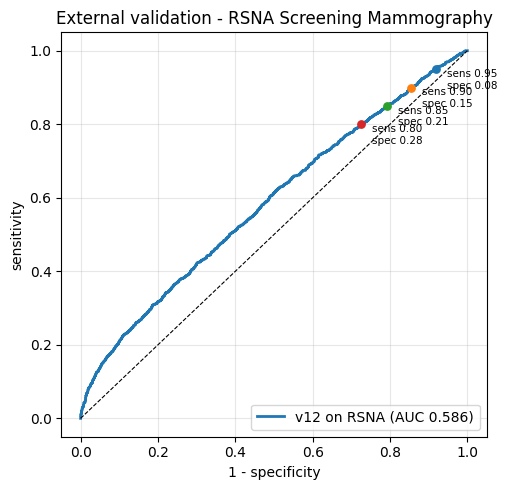

In [12]:
AUC = roc_auc_score(y, score)
fpr, tpr, thr = roc_curve(y, score)

def boot_auc(y, s, n=2000):
    rng = np.random.default_rng(SEED); out = []
    idx = np.arange(len(y))
    for _ in range(n):
        b = rng.choice(idx, len(idx), replace=True)
        if y[b].sum() in (0, len(b)): continue
        out.append(roc_auc_score(y[b], s[b]))
    return np.percentile(out, [2.5, 97.5])

lo, hi = boot_auc(y, score)
print(f'EXTERNAL ROC-AUC = {AUC:.4f}   95% CI [{lo:.4f}, {hi:.4f}]')
print(f'internal malignant-vs-rest AUC was {V12_INTERNAL["macro_auc"]:.4f} macro / 0.8673 mal-vs-rest')

plt.figure(figsize=(5.2, 5))
plt.plot(fpr, tpr, lw=2, label=f'v12 on RSNA (AUC {AUC:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=.8)
for s_t in [0.95, 0.90, 0.85, 0.80]:
    i = int(np.argmin(np.abs(tpr - s_t)))
    plt.scatter([fpr[i]], [tpr[i]], s=28, zorder=5)
    plt.annotate(f'sens {tpr[i]:.2f}\nspec {1-fpr[i]:.2f}', (fpr[i], tpr[i]),
                 textcoords='offset points', xytext=(8, -14), fontsize=7.5)
plt.xlabel('1 - specificity'); plt.ylabel('sensitivity')
plt.title('External validation - RSNA Screening Mammography')
plt.legend(loc='lower right'); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## 8. Screening metrics at true prevalence

Sensitivity and specificity are unaffected by how the negatives were sampled. PPV, recall rate
and cancer detection rate are functions of prevalence, so they are projected analytically onto
the full-release prevalence rather than read off the enriched sample.

projected to prevalence 0.0212 (21.2 cancers per 1,000 screens)



,threshold,sensitivity,specificity,PPV_%,recall_per_1000,cancers_found_per_1000,cancers_missed_per_1000
target_sens,,,,,,,
0.95,0.2961,0.9499,0.0818,2.188,918.8,20.11,1.06
0.90,0.3529,0.8998,0.1468,2.230,854.2,19.05,2.12
0.85,0.3965,0.8497,0.2070,2.265,794.2,17.99,3.18
0.80,0.4363,0.7997,0.2755,2.331,726.1,16.93,4.24
0.70,0.5002,0.7003,0.3959,2.446,606.2,14.82,6.34


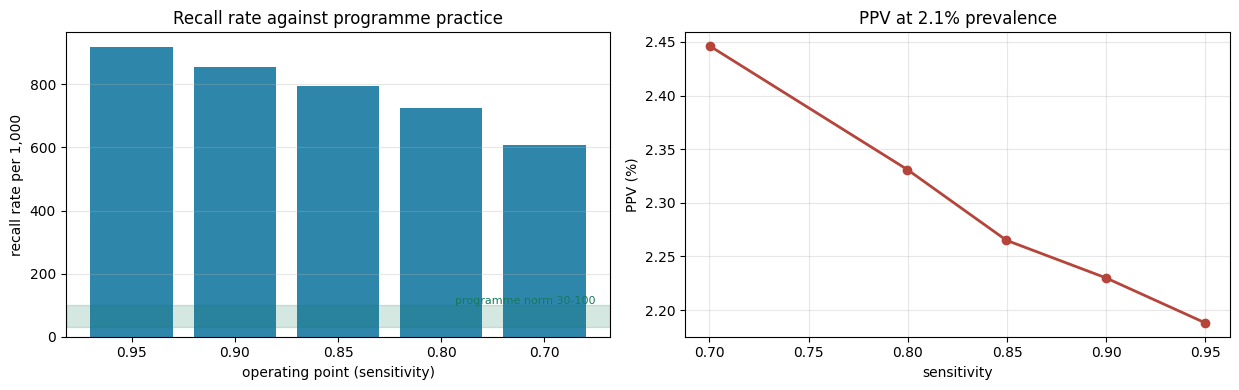

In [13]:
rows = []
for target in [0.95, 0.90, 0.85, 0.80, 0.70]:
    i = int(np.argmin(np.abs(tpr - target)))
    sens, spec, t = tpr[i], 1 - fpr[i], thr[i]
    tp = sens * PREV; fp = (1 - spec) * (1 - PREV)
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rows.append({'target_sens': target, 'threshold': round(float(t), 4),
                 'sensitivity': round(float(sens), 4), 'specificity': round(float(spec), 4),
                 'PPV_%': round(100*ppv, 3),
                 'recall_per_1000': round(1000*(tp + fp), 1),
                 'cancers_found_per_1000': round(1000*tp, 2),
                 'cancers_missed_per_1000': round(1000*(PREV - tp), 2)})
ops = pd.DataFrame(rows).set_index('target_sens')
print(f'projected to prevalence {PREV:.4f} ({1000*PREV:.1f} cancers per 1,000 screens)\n')
display(ops)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
ax[0].bar(range(len(ops)), ops['recall_per_1000'], color='#2E86AB')
ax[0].axhspan(30, 100, color='#147A5A', alpha=.18)
ax[0].text(len(ops)-0.5, 105, 'programme norm 30-100', ha='right', fontsize=8, color='#147A5A')
ax[0].set_xticks(range(len(ops))); ax[0].set_xticklabels([f'{v:.2f}' for v in ops.index])
ax[0].set_xlabel('operating point (sensitivity)'); ax[0].set_ylabel('recall rate per 1,000')
ax[0].set_title('Recall rate against programme practice'); ax[0].grid(alpha=.3, axis='y')
ax[1].plot(ops['sensitivity'], ops['PPV_%'], 'o-', lw=2, color='#B5453B')
ax[1].set_xlabel('sensitivity'); ax[1].set_ylabel('PPV (%)')
ax[1].set_title(f'PPV at {100*PREV:.1f}% prevalence'); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 9. The external shortcut test

RSNA has two sites and ten scanner models, none of which the network has seen. If the DRO
result is real, detection should be roughly even across them.

**One measurement trap, checked against `train.csv` before writing this.** The internal
shortcut slope was fitted over source priors spanning 0.042 to 0.797 — a range of 0.755.
RSNA's scanner priors span 0.0042 to 0.0345, a range of 0.030. The internal x-axis is
**25 times wider**.

A slope of 0.287 therefore implies 0.217 of recall spread internally, but only 0.009 here.
**Quoting an RSNA slope against the internal 0.287 would be meaningless.** So the headline
numbers below are scale-free — Pearson correlation between a scanner's own cancer rate and
its sensitivity, plus the raw sensitivity spread. The slope is still printed, with the recall
spread it implies, but it is not the comparison to make.

Sites get a spread rather than a slope: there are only two of them, their prevalences are
nearly identical (0.0225 vs 0.0196), and a line through two points fits perfectly by
construction.

operating point: sensitivity 0.8998, threshold 0.3529

BY SITE   (2 sites, near-identical prevalence - spread only)


,n,n_cancer,true_prior,auc,sens,ci_lo,ci_hi,spec
site_id,,,,,,,,
1,8632,664,0.02249,0.5798,0.9142,0.8902,0.9343,0.0931
2,6422,494,0.01961,0.5987,0.8806,0.8487,0.9078,0.2190



   sensitivity spread : 0.0336   (max - min across groups)
   AUC spread         : 0.0189
   only 2 groups - no slope fitted

BY SCANNER


,n,n_cancer,true_prior,auc,sens,ci_lo,ci_hi,spec
machine_id,,,,,,,,
21,2076,154,0.01873,0.5595,0.8052,0.7337,0.8645,0.2747
29,2086,161,0.01948,0.6856,0.8447,0.7794,0.8969,0.3538
48,2260,179,0.02058,0.5981,0.9777,0.9438,0.9939,0.0428
49,6936,614,0.02610,0.5681,0.9088,0.8832,0.9304,0.1050
93,539,14,0.00731,0.7054,1.0000,0.7684,1.0000,0.0286
170,258,23,0.02492,0.5680,0.9565,0.7805,0.9989,0.0553
190,48,5,0.03448,0.7163,1.0000,0.4782,1.0000,0.0698
216,543,8,0.00419,0.6925,1.0000,0.6306,1.0000,0.0318



   sensitivity spread : 0.1948   (max - min across groups)
   AUC spread         : 0.1568
   Pearson r          : -0.1371   <- scale-free, this is the one to read
   slope              : +2.5563 over a prior range of only 0.0303
   implied spread     : +0.0774 of recall (internal was 0.287 x 0.755 = 0.217)

   Reading it: r near 0 means detection is independent of which scanner took
   the image. r near +1 means the model is still reproducing each machine's
   own cancer rate - the same failure the internal audit found, on data it has
   never seen. Sensitivity spread is the practical magnitude.


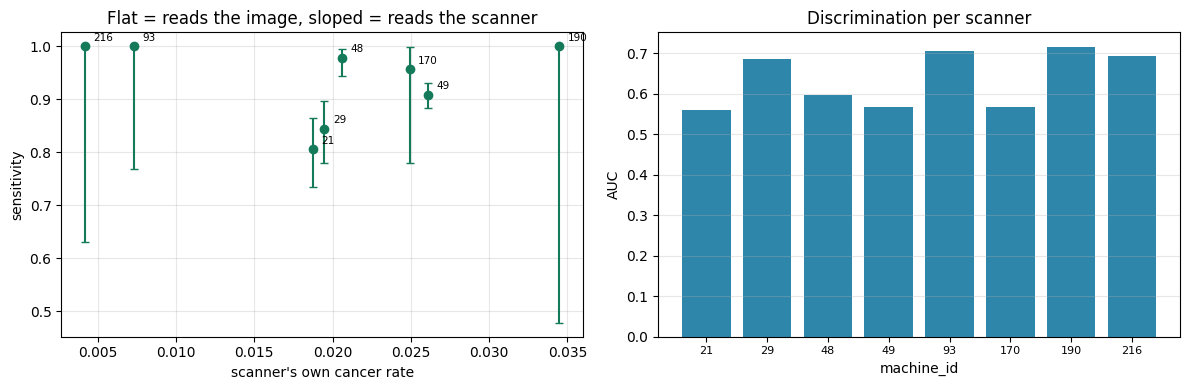

In [14]:
def clopper_pearson(k, n, alpha=0.05):
    if n == 0: return (float('nan'), float('nan'))
    lo = 0.0 if k == 0 else _beta.ppf(alpha/2, k, n-k+1)
    hi = 1.0 if k == n else _beta.ppf(1-alpha/2, k+1, n-k)
    return float(lo), float(hi)

OP = 0.90
i90 = int(np.argmin(np.abs(tpr - OP))); THR90 = thr[i90]
pred90 = (score >= THR90).astype(int)

def group_table(col, min_pos=5, min_neg=5):
    prior_map = TRUE_PRIOR.get(col, {})
    out = []
    for g, idx in ev.groupby(col).groups.items():
        m = ev.index.isin(idx)
        yg, pg, sg = y[m], pred90[m], score[m]
        n_pos = int(yg.sum()); n_neg = int(len(yg) - n_pos)
        if n_pos < min_pos or n_neg < min_neg: continue
        hits = int(((yg == 1) & (pg == 1)).sum())
        lo, hi = clopper_pearson(hits, n_pos)
        out.append({str(col): g, 'n': int(m.sum()), 'n_cancer': n_pos,
                    'true_prior': round(float(prior_map.get(g, n_pos/max(len(yg),1))), 5),
                    'auc': round(roc_auc_score(yg, sg), 4),
                    'sens': round(hits/n_pos, 4), 'ci_lo': round(lo, 4), 'ci_hi': round(hi, 4),
                    'spec': round(float(((yg == 0) & (pg == 0)).sum() / max(n_neg, 1)), 4)})
    return pd.DataFrame(out).set_index(str(col))

def shortcut_report(tab, label):
    # Scale-free first. The slope depends on how wide the prior range happens to be,
    # so it cannot be compared between datasets with different prior spreads.
    t = tab.dropna(subset=['true_prior'])
    out = {'n_groups': len(t), 'sens_spread': float(t.sens.max() - t.sens.min()),
           'auc_spread': float(t.auc.max() - t.auc.min())}
    print(f'{label}')
    print(f'   sensitivity spread : {out["sens_spread"]:.4f}   (max - min across groups)')
    print(f'   AUC spread         : {out["auc_spread"]:.4f}')
    if len(t) >= 3:
        x = t['true_prior'].to_numpy(float); yv = t['sens'].to_numpy(float)
        w = np.sqrt(t['n_cancer'].to_numpy(float))
        sl = float(np.polyfit(x, yv, 1, w=w)[0])
        r  = float(np.corrcoef(x, yv)[0, 1])
        rng = float(x.max() - x.min())
        out.update({'slope': sl, 'pearson_r': r, 'prior_range': rng,
                    'implied_recall_spread': sl * rng})
        print(f'   Pearson r          : {r:+.4f}   <- scale-free, this is the one to read')
        print(f'   slope              : {sl:+.4f} over a prior range of only {rng:.4f}')
        print(f'   implied spread     : {sl*rng:+.4f} of recall '
              f'(internal was 0.287 x 0.755 = 0.217)')
    else:
        print(f'   only {len(t)} groups - no slope fitted')
    return out

print(f'operating point: sensitivity {tpr[i90]:.4f}, threshold {THR90:.4f}\n')

print('BY SITE   (2 sites, near-identical prevalence - spread only)')
site_tab = group_table('site_id'); display(site_tab)
SITE_STATS = shortcut_report(site_tab, '')

MACH_STATS, mach_tab = None, None
if 'machine_id' in ev.columns:
    print('\nBY SCANNER')
    mach_tab = group_table('machine_id'); display(mach_tab)
    MACH_STATS = shortcut_report(mach_tab, '')
    print('\n   Reading it: r near 0 means detection is independent of which scanner took')
    print('   the image. r near +1 means the model is still reproducing each machine\'s')
    print('   own cancer rate - the same failure the internal audit found, on data it has')
    print('   never seen. Sensitivity spread is the practical magnitude.')

    if len(mach_tab) >= 3:
        fig, ax9 = plt.subplots(1, 2, figsize=(12, 4))
        ax9[0].errorbar(mach_tab.true_prior, mach_tab.sens,
                        yerr=[mach_tab.sens - mach_tab.ci_lo, mach_tab.ci_hi - mach_tab.sens],
                        fmt='o', capsize=3, color='#147A5A')
        for mid, r_ in mach_tab.iterrows():
            ax9[0].annotate(str(mid), (r_.true_prior, r_.sens), fontsize=7.5,
                            textcoords='offset points', xytext=(6, 4))
        ax9[0].set_xlabel("scanner's own cancer rate"); ax9[0].set_ylabel('sensitivity')
        ax9[0].set_title('Flat = reads the image, sloped = reads the scanner')
        ax9[0].grid(alpha=.3)
        ax9[1].bar(range(len(mach_tab)), mach_tab.auc, color='#2E86AB')
        ax9[1].set_xticks(range(len(mach_tab)))
        ax9[1].set_xticklabels(mach_tab.index, fontsize=8)
        ax9[1].set_xlabel('machine_id'); ax9[1].set_ylabel('AUC')
        ax9[1].set_title('Discrimination per scanner'); ax9[1].grid(alpha=.3, axis='y')
        plt.tight_layout(); plt.show()

### 9a. Subgroups RSNA gives away for free

`train.csv` carries columns worth reporting that cost nothing extra to compute, and two of
them are plausible systematic failure modes rather than curiosities.

**Implants** — 1,477 images. Mammo-Bench contains few if any, so this is genuinely
out-of-distribution input, and an implant changes the image far more than a scanner does.

**Difficult negatives** — 7,705 images the organisers flagged as hard. Specificity here is a
better guide to real recall burden than specificity on easy negatives.

**Invasive vs non-invasive** — 818 of the cancers are invasive. Missing an invasive cancer
matters more than missing DCIS.

**Density** — site 1 only. Dense breasts are the known hard case in screening, and the model
was trained with density as an auxiliary label in some variants.

In [15]:
def subgroup(mask, name, note=''):
    if mask.sum() == 0: return None
    yg, pg, sg = y[mask], pred90[mask], score[mask]
    n_pos = int(yg.sum()); n_neg = int(len(yg) - n_pos)
    if n_pos < 3 or n_neg < 3: 
        print(f'{name:34s} n={mask.sum():6d}  too few of one class to report'); return None
    hits = int(((yg == 1) & (pg == 1)).sum())
    lo, hi = clopper_pearson(hits, n_pos)
    auc = roc_auc_score(yg, sg) if n_pos and n_neg else float('nan')
    row = {'group': name, 'n': int(mask.sum()), 'n_cancer': n_pos,
           'sens': hits/n_pos, 'ci_lo': lo, 'ci_hi': hi,
           'spec': float(((yg == 0) & (pg == 0)).sum() / max(n_neg, 1)), 'auc': auc}
    print(f'{name:34s} n={row["n"]:6d}  cancers={n_pos:4d}  sens={row["sens"]:.4f} '
          f'[{lo:.3f},{hi:.3f}]  spec={row["spec"]:.4f}  auc={auc:.4f}  {note}')
    return row

rows = []
print('SUBGROUPS at the 90%-sensitivity operating point\n')
if 'implant' in ev.columns:
    rows += [subgroup((ev.implant == 0).to_numpy(), 'no implant'),
             subgroup((ev.implant == 1).to_numpy(), 'IMPLANT (out of distribution)')]
if 'difficult_negative_case' in ev.columns:
    d = ev.difficult_negative_case.astype(bool).to_numpy()
    rows += [subgroup(~d, 'easy negatives'), subgroup(d, 'DIFFICULT negatives')]
if 'invasive' in ev.columns:
    inv = (ev.invasive == 1).to_numpy(); can = (ev.cancer == 1).to_numpy()
    n_inv = int((inv & can).sum()); n_non = int((~inv & can).sum())
    h_inv = int((inv & can & (pred90 == 1)).sum()); h_non = int((~inv & can & (pred90 == 1)).sum())
    if n_inv >= 3:
        lo, hi = clopper_pearson(h_inv, n_inv)
        print(f'{"invasive cancers":34s} n={n_inv:6d}  sens={h_inv/n_inv:.4f} [{lo:.3f},{hi:.3f}]')
    if n_non >= 3:
        lo, hi = clopper_pearson(h_non, n_non)
        print(f'{"non-invasive cancers":34s} n={n_non:6d}  sens={h_non/n_non:.4f} [{lo:.3f},{hi:.3f}]')
if 'density' in ev.columns and ev.density.notna().any():
    print()
    for d_ in ['A', 'B', 'C', 'D']:
        m_ = (ev.density == d_).to_numpy()
        if m_.sum(): rows.append(subgroup(m_, f'density {d_}'))
if 'age' in ev.columns:
    print()
    for lo_, hi_ in [(0, 50), (50, 60), (60, 70), (70, 200)]:
        m_ = ((ev.age >= lo_) & (ev.age < hi_)).to_numpy()
        if m_.sum(): rows.append(subgroup(m_, f'age {lo_}-{hi_ if hi_ < 200 else "+"}'))

SUBGROUPS = pd.DataFrame([r for r in rows if r]).set_index('group').round(4) if any(rows) else None
print('\nThe implant row is the one to look at hardest - it is the clearest')
print('out-of-distribution input in this dataset.')

SUBGROUPS at the 90%-sensitivity operating point

no implant                         n= 14628  cancers=1145  sens=0.8987 [0.880,0.916]  spec=0.1492  auc=0.5877  
IMPLANT (out of distribution)      n=   426  cancers=  13  sens=1.0000 [0.753,1.000]  spec=0.0678  auc=0.6618  
easy negatives                     n= 13053  cancers=1158  sens=0.8998 [0.881,0.917]  spec=0.1478  auc=0.5879  
DIFFICULT negatives                n=  2001  too few of one class to report
invasive cancers                   n=   818  sens=0.9267 [0.907,0.944]
non-invasive cancers               n=   340  sens=0.8353 [0.792,0.873]

density A                          n=   928  cancers=  53  sens=1.0000 [0.933,1.000]  spec=0.0629  auc=0.6678  
density B                          n=  3651  cancers= 309  sens=0.9579 [0.929,0.977]  spec=0.0697  auc=0.6171  
density C                          n=  3562  cancers= 277  sens=0.8700 [0.825,0.907]  spec=0.1081  auc=0.5428  
density D                          n=   475  cancers=  25  

## 10. Breast-level and the summary the report needs

In [16]:
# RSNA labels a breast, not an image - aggregate views by max score per patient x laterality
bl = pd.DataFrame({'pid': ev.patient_id, 'lat': ev.laterality, 'y': y, 's': score})
g = bl.groupby(['pid', 'lat']).agg(y=('y', 'max'), s=('s', 'max')).reset_index()
bl_auc = roc_auc_score(g.y, g.s)
bf, bt, bthr = roc_curve(g.y, g.s)
j = int(np.argmin(np.abs(bt - 0.90)))
print(f'BREAST LEVEL: {len(g)} breasts, {int(g.y.sum())} with cancer')
print(f'  AUC {bl_auc:.4f}   at sensitivity {bt[j]:.4f} specificity {1-bf[j]:.4f}')

print('\n' + '='*74)
print('SUMMARY - v12 ensemble, internal vs external')
print('='*74)
r90 = ops.loc[0.90]
summary = {
 'Internal (Mammo-Bench, 44.5% prevalence)': {
    'malignant recall': f'{V12_INTERNAL["mal_recall"]:.4f}',
    'macro AUC': f'{V12_INTERNAL["macro_auc"]:.4f}',
    'shortcut slope': f'{V12_INTERNAL["slope"]:.4f}'},
 f'External (RSNA, {100*PREV:.1f}% prevalence)': {
    'sensitivity @ operating point': f'{r90["sensitivity"]:.4f}',
    'specificity': f'{r90["specificity"]:.4f}',
    'ROC-AUC (image)': f'{AUC:.4f}',
    'ROC-AUC (breast)': f'{bl_auc:.4f}',
    'PPV': f'{r90["PPV_%"]:.2f}%',
    'recall per 1,000': f'{r90["recall_per_1000"]:.0f}',
    'cancers found per 1,000': f'{r90["cancers_found_per_1000"]:.2f}'},
}
for k, v in summary.items():
    print(f'\n{k}')
    for kk, vv in v.items(): print(f'   {kk:32s} {vv}')
if CONTROL:
    print(f'\nPreprocessing control: malignant recall {V12_INTERNAL["mal_recall"]:.4f} -> '
          f'{CONTROL["mal_recall"]:.4f} on the section 4 pipeline '
          f'({100*(CONTROL["mal_recall"]-V12_INTERNAL["mal_recall"]):+.2f} pts).')
    print('Any further drop on RSNA is population, not pipeline.')

json.dump({'auc_image': float(AUC), 'auc_image_ci': [float(lo), float(hi)],
           'auc_breast': float(bl_auc), 'prevalence': float(PREV),
           'n_images': int(len(y)), 'n_cancers': int(y.sum()),
           'operating_points': ops.reset_index().to_dict('records'),
           'by_site': site_tab.reset_index().to_dict('records'),
           'by_machine': (mach_tab.reset_index().to_dict('records') if mach_tab is not None else None),
           'site_shortcut_stats': SITE_STATS, 'scanner_shortcut_stats': MACH_STATS,
           'subgroups': (SUBGROUPS.reset_index().to_dict('records') if SUBGROUPS is not None else None),
           'preproc_control': CONTROL, 'internal': V12_INTERNAL,
           'ensemble': {'members': ENS['members'], 'coef': ENS['class_coefficients']}},
          open(os.path.join(OUT_DIR, 'rsna_external_results.json'), 'w'), indent=2)
print('\nSaved:', os.path.join(OUT_DIR, 'rsna_external_results.json'))

BREAST LEVEL: 11903 breasts, 492 with cancer
  AUC 0.6945   at sensitivity 0.9004 specificity 0.3089

SUMMARY - v12 ensemble, internal vs external

Internal (Mammo-Bench, 44.5% prevalence)
   malignant recall                 0.7643
   macro AUC                        0.8810
   shortcut slope                   0.2868

External (RSNA, 2.1% prevalence)
   sensitivity @ operating point    0.8998
   specificity                      0.1468
   ROC-AUC (image)                  0.5855
   ROC-AUC (breast)                 0.6945
   PPV                              2.23%
   recall per 1,000                 854
   cancers found per 1,000          19.05

Preprocessing control: malignant recall 0.7643 -> 0.8662 on the section 4 pipeline (+10.19 pts).
Any further drop on RSNA is population, not pipeline.

Saved: /kaggle/working/rsna_external_results.json


## How to read this

**Read the preprocessing control before the headline.** If section 6a shows malignant recall
dropping several points on Mammo-Bench images purely from the pipeline change, then that much
of the RSNA drop is plumbing rather than generalisation, and the honest external number is the
RSNA figure adjusted for it.

**Expect a drop, and say so in advance.** Model choices have been made against the same
830-patient selection set across two sprints, and this is a different population, different
scanners and a different preprocessing chain. An AUC in the high 0.70s to low 0.80s would be a
respectable result for a model trained on 13,900 research images and never fine-tuned here.
Published screening systems train on hundreds of thousands.

**Section 9 is the real prize.** A flat profile across RSNA sites and scanners is independent
confirmation that Group DRO fixed the shortcut, on data no part of this project has touched.
A profile that splits by scanner means it did not — and that would be worth knowing far more
than a good AUC.

**What this still cannot tell you.** RSNA is binary, so the Benign boundary is untested and
continues to rest on the Mammo-Bench comparison. And the recall rate will very likely sit
above the 30–100 per 1,000 programme band; that is a statement about a research model, not a
failure of this experiment.

## Then

Whatever the number, it is the first figure in this project that can be put beside a
commercial system without a caveat about cohort enrichment — Lunit's 0.903 and Transpara's
0.840 were measured in this regime. Take it, the preprocessing control, and the section 9
site breakdown into the report.